# Laboratorio 06 - Lab04: Regresión Logística con PyTorch

## Clasificación de Malware con CIC-MalMem-2022

**Estudiante:** Karen Villarpando Olmedo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# 2. Cargar el dataset

In [5]:
ruta = 'MalMem2022.csv'

df = pd.read_csv(ruta)

print("Dataset cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Dataset cargado correctamente
Filas: 58596
Columnas: 58


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,...,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,...,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,...,27,118,0,120,88,0,8,Benign,Benign,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,...,24,118,0,124,87,0,8,Benign,Benign,Benign


# 3. Exploración y preprocesamiento

In [7]:
# Exploración del dataset

print("Dimensiones:", df.shape)

print("\nValores nulos totales:")
print(df.isnull().sum().sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

print("\nDistribución de Class:")
print(df['Class'].value_counts())

print("\nPorcentaje por clase:")
print((df['Class'].value_counts(normalize=True) * 100).round(2))

Dimensiones: (58596, 58)

Valores nulos totales:
0

Filas duplicadas:
534

Distribución de Class:
Class
Benign     29298
Malware    29298
Name: count, dtype: int64

Porcentaje por clase:
Class
Benign     50.0
Malware    50.0
Name: proportion, dtype: float64


# 4. Limpieza de duplicados

In [8]:
# Eliminar duplicados

df = df.drop_duplicates().reset_index(drop=True)

print("Datos después de eliminar duplicados:", df.shape)

Datos después de eliminar duplicados: (58062, 58)


# 5. Preparación de X e y

In [9]:
# Convertir la clase a valores binarios
df['Class'] = df['Class'].map({
    'Benign': 0,
    'Malware': 1
})

# Variables predictoras
columnas_x = [
    col for col in df.columns
    if col not in ['Class', 'Category', 'Filename']
]

X = df[columnas_x].values.astype(np.float32)
y = df['Class'].values.astype(np.float32)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("Número de variables predictoras:", len(columnas_x))

print("\nDistribución de clases:")
print(pd.Series(y).value_counts().sort_index())

Forma de X: (58062, 55)
Forma de y: (58062,)
Número de variables predictoras: 55

Distribución de clases:
0.0    29231
1.0    28831
Name: count, dtype: int64


# 6. División entrenamiento y prueba

In [10]:
# División 80% entrenamiento - 20% prueba

np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

tam_train = int(0.8 * len(X))

idx_train = indices[:tam_train]
idx_test = indices[tam_train:]

X_train = X[idx_train]
y_train = y[idx_train]

X_test = X[idx_test]
y_test = y[idx_test]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (46449, 55)
y_train: (46449,)
X_test: (11613, 55)
y_test: (11613,)


# 7. Normalización

In [11]:
# Normalización

media = X_train.mean(axis=0)
desv = X_train.std(axis=0)

# Evitar división entre cero
desv[desv == 0] = 1

X_train_norm = (X_train - media) / desv
X_test_norm = (X_test - media) / desv

print("Dimensión X_train normalizado:", X_train_norm.shape)
print("Dimensión X_test normalizado:", X_test_norm.shape)

print("\nMedia aproximada:")
print(X_train_norm.mean(axis=0)[:10])

print("\nDesviación aproximada:")
print(X_train_norm.std(axis=0)[:10])

Dimensión X_train normalizado: (46449, 55)
Dimensión X_test normalizado: (11613, 55)

Media aproximada:
[ 2.12114983e-07 -2.20894822e-08  1.90526280e-05  0.00000000e+00
 -7.82172208e-07  1.10676665e-04  2.34199309e-04 -2.11426050e-06
 -3.45046215e-06  0.00000000e+00]

Desviación aproximada:
[1.0000436  0.9999943  1.000002   0.         0.99999887 0.9999919
 1.0000018  0.99999994 1.0000008  0.        ]


# 8. Tensores, Dataset y DataLoader

In [12]:
# Convertir a tensores

X_train_tensor = torch.tensor(
    X_train_norm,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).view(-1, 1)

X_test_tensor = torch.tensor(
    X_test_norm,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).view(-1, 1)


# Crear Dataset

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


# Crear DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


print("Tamaño train_dataset:", len(train_dataset))
print("Tamaño test_dataset:", len(test_dataset))

print("Número de lotes de entrenamiento:", len(train_loader))
print("Número de lotes de prueba:", len(test_loader))

# Ver un lote
X_batch, y_batch = next(iter(train_loader))

print("\nForma de X_batch:", X_batch.shape)
print("Forma de y_batch:", y_batch.shape)

Tamaño train_dataset: 46449
Tamaño test_dataset: 11613
Número de lotes de entrenamiento: 1452
Número de lotes de prueba: 363

Forma de X_batch: torch.Size([32, 55])
Forma de y_batch: torch.Size([32, 1])


# 9. Red neuronal PyTorch

In [13]:
# Red neuronal para clasificación binaria

model = nn.Sequential(
    nn.Linear(55, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=55, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)


# 10. Función de pérdida y optimizador

In [14]:
# Función de pérdida
criterion = nn.BCEWithLogitsLoss()

# Optimizador
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Función de pérdida:", criterion)
print("Optimizador:", optimizer.__class__.__name__)

Función de pérdida: BCEWithLogitsLoss()
Optimizador: Adam


# 11. Entrenamiento de la red neuronal

In [15]:
# Entrenamiento

epochs = 100
loss_history = []

for epoch in range(1, epochs + 1):

    model.train()
    loss_epoch = 0

    for X_batch, y_batch in train_loader:

        # Forward
        y_pred = model(X_batch)

        # Calcular pérdida
        loss = criterion(y_pred, y_batch)

        # Reiniciar gradientes
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Actualizar pesos
        optimizer.step()

        loss_epoch += loss.item()

    # Pérdida promedio de la época
    loss_promedio = loss_epoch / len(train_loader)
    loss_history.append(loss_promedio)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss: {loss_promedio:.4f}")

Epoch 10/100 - Loss: 0.0006
Epoch 20/100 - Loss: 0.0002
Epoch 30/100 - Loss: 0.0001
Epoch 40/100 - Loss: 0.0000
Epoch 50/100 - Loss: 0.0000
Epoch 60/100 - Loss: 0.0000
Epoch 70/100 - Loss: 0.0000
Epoch 80/100 - Loss: 0.0000
Epoch 90/100 - Loss: 0.0000
Epoch 100/100 - Loss: 0.0000


# 12. Gráfica de pérdida

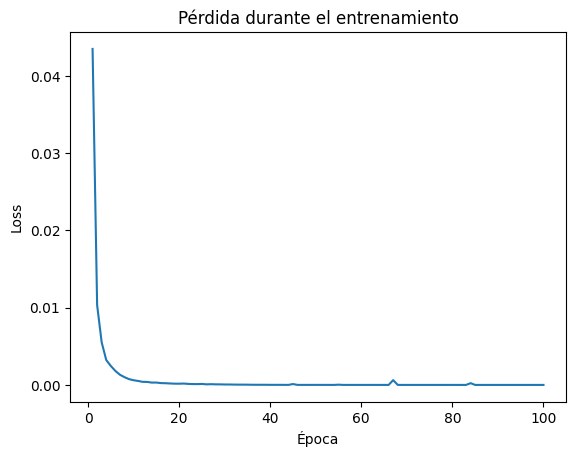

In [16]:
# Gráfica de la pérdida

plt.plot(range(1, epochs + 1), loss_history)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Pérdida durante el entrenamiento")

plt.show()

# 13. Predicciones sobre el conjunto de prueba

In [17]:
# Predicciones sobre el conjunto de prueba

model.eval()

with torch.no_grad():

    # Salida de la red
    logits = model(X_test_tensor)

    # Convertir logits a probabilidades
    probabilidades = torch.sigmoid(logits)

    # Clasificar con umbral 0.5
    predicciones = (probabilidades >= 0.5).float()


# Convertir a NumPy
probabilidades = probabilidades.numpy().flatten()
predicciones = predicciones.numpy().flatten()

print(f"{'Real':>8} {'Probabilidad':>15} {'Predicción':>15}")
print("-" * 42)

for i in range(10):
    print(
        f"{y_test[i]:8.0f} "
        f"{probabilidades[i]:15.4f} "
        f"{predicciones[i]:15.0f}"
    )

    Real    Probabilidad      Predicción
------------------------------------------
       1          1.0000               1
       1          1.0000               1
       0          0.0000               0
       0          0.0000               0
       0          0.0000               0
       1          1.0000               1
       0          0.0000               0
       0          0.0000               0
       0          0.0000               0
       1          1.0000               1


# 14. Métricas de clasificación

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, predicciones)
precision = precision_score(y_test, predicciones)
recall = recall_score(y_test, predicciones)
f1 = f1_score(y_test, predicciones)

matriz = confusion_matrix(y_test, predicciones)

print("Métricas del modelo")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nMatriz de confusión:")
print(matriz)

Métricas del modelo
-------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Matriz de confusión:
[[5942    0]
 [   0 5671]]


# 15. Inferencia con una muestra nueva

In [19]:
# Tomar una muestra del conjunto de prueba
muestra = X_test_tensor[0].view(1, -1)

# Clase real
clase_real = y_test[0]

model.eval()

with torch.no_grad():
    salida = model(muestra)

    probabilidad = torch.sigmoid(salida).item()

    prediccion = 1 if probabilidad >= 0.5 else 0

print(f"Clase real: {clase_real:.0f}")
print(f"Probabilidad de Malware: {probabilidad:.4f}")
print(f"Predicción final (0=Benign, 1=Malware): {prediccion}")

Clase real: 1
Probabilidad de Malware: 1.0000
Predicción final (0=Benign, 1=Malware): 1


# 16. Guardar los pesos del modelo

In [20]:
from google.colab import drive
drive.mount('/content/gdrive')

ruta_modelo = '/content/gdrive/MyDrive/modelo_lab04_karen_pytorch.pth'

torch.save(model.state_dict(), ruta_modelo)

print("Modelo guardado correctamente")
print("Ruta:", ruta_modelo)

Mounted at /content/gdrive
Modelo guardado correctamente
Ruta: /content/gdrive/MyDrive/modelo_lab04_karen_pytorch.pth
